In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

In [6]:
df = pd.read_csv("Clarity_Export_Healy_Kurt_2026-04-03_025418.csv", skiprows=11)
bg = df[['11', 'iOS G7']]
bg["11"] = pd.to_datetime(bg["11"])
march30 = bg[bg["11"].dt.date == pd.to_datetime("2026-03-30").date()]
march30['iOS G7'] = pd.to_numeric(march30['iOS G7'], errors='coerce')

/var/folders/fz/sp5lcgpj7n39l12p5kslyw980000gn/T/ipykernel_64832/3319873569.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  bg["11"] = pd.to_datetime(bg["11"])
/var/folders/fz/sp5lcgpj7n39l12p5kslyw980000gn/T/ipykernel_64832/3319873569.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  march30['iOS G7'] = pd.to_numeric(march30['iOS G7'], errors='coerce')


/var/folders/fz/sp5lcgpj7n39l12p5kslyw980000gn/T/ipykernel_64832/694645684.py:98: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45)


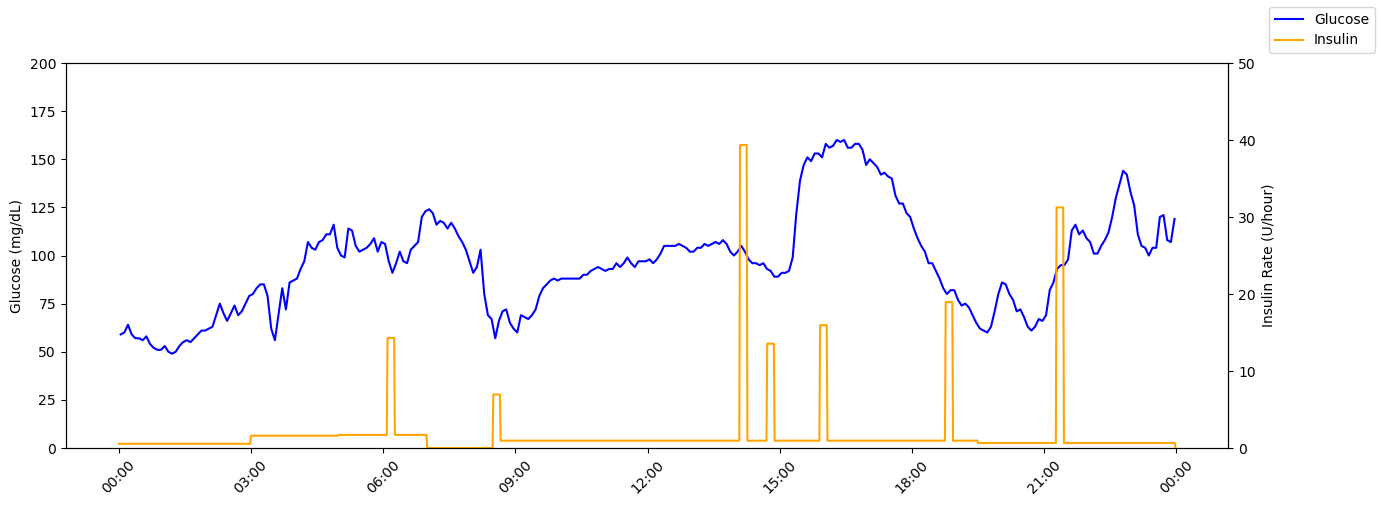

In [7]:
date = "2026-03-30"

schedule = [
    ("00:00", "03:00", 0.550),
    ("03:00", "05:00", 1.6),
    ("05:00", "07:00", 1.7),
    ("07:00", "08:30", 0.0),
    ("08:30", "19:30", 0.95),
    ("19:30", "23:59", 0.650),
]

boluses = [
    ("06:06", 2.1),
    ("08:30", 1.0),
    ("14:06", 6.4),
    ("14:43", 2.1),
    ("15:55", 2.5),
    ("18:46", 3.0),
    ("21:17", 5.1),
]

# -----------------------------
# Basal dataframe
# -----------------------------
insulin_df = pd.DataFrame(schedule, columns=["start", "end", "rate"])
insulin_df["start"] = pd.to_datetime(date + " " + insulin_df["start"])
insulin_df["end"] = pd.to_datetime(date + " " + insulin_df["end"])

# -----------------------------
# Bolus dataframe
# -----------------------------
bolus_df = pd.DataFrame(boluses, columns=["time", "dose"])
bolus_df["timestamp"] = pd.to_datetime(date + " " + bolus_df["time"])

def expand_bolus(row):
    times = pd.date_range(start=row["timestamp"], periods=10, freq="1min")
    per_minute = row["dose"] * 6
    return pd.DataFrame({"timestamp": times, "bolus_rate": per_minute})

expanded_boluses = pd.concat(
    [expand_bolus(row) for _, row in bolus_df.iterrows()],
    ignore_index=True
)

# -----------------------------
# Time grid
# -----------------------------
time_index = pd.date_range(
    start=f"{date} 00:00",
    end=f"{date} 23:59",
    freq="1min"
)

insulin_series = pd.DataFrame({"timestamp": time_index})

# -----------------------------
# Basal rate assignment
# -----------------------------
def get_basal_rate(t):
    for _, row in insulin_df.iterrows():
        if row["start"] <= t < row["end"]:
            return row["rate"]
    return 0

insulin_series["basal"] = insulin_series["timestamp"].apply(get_basal_rate)

# -----------------------------
# Add bolus contributions
# -----------------------------
bolus_agg = expanded_boluses.groupby("timestamp")["bolus_rate"].sum().reset_index()

insulin_series = insulin_series.merge(bolus_agg, on="timestamp", how="left")
insulin_series["bolus_rate"] = insulin_series["bolus_rate"].fillna(0)

# Total insulin
insulin_series["total_insulin"] = insulin_series["basal"] + insulin_series["bolus_rate"]

# -----------------------------
# Plot with dual y-axes
# -----------------------------
fig, ax1 = plt.subplots(figsize=(15, 5))

# Glucose (left axis)
ax1.plot(march30["11"], march30["iOS G7"], label="Glucose", color="blue")
ax1.set_ylabel("Glucose (mg/dL)")
ax1.set_ylim(0, 200)

# Format x-axis as time of day
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))

# Insulin (right axis)
ax2 = ax1.twinx()
ax2.set_ylim(0, 50)
ax2.plot(insulin_series["timestamp"], insulin_series["total_insulin"], label="Insulin", color="orange")
ax2.set_ylabel("Insulin Rate (U/hour)")

# Formatting
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45)
fig.legend(loc="upper right")

plt.show()

Now apply our control.

In [8]:
import numpy as np
import scipy.linalg
import scipy.signal
import matplotlib.pyplot as plt
import numpy as np
plt.rcParams["figure.dpi"] = 500
class CGM():
    def __init__(self, a, b, c, d, dt, glucose_penalty, insulin_penalty, controller_penalty, derivitive_penalty, target=83, base_insulin=10):
        # This is our target glucose measurement 
        self.target = target
        # This is the baseline amount of insulin
        self.base_insulin = base_insulin 
        # Our model will penalize the difference between the current state and these baselines

        # Define evolution matrices for AX + Bu
        A = np.array([[-a, -b], [d, -c]])
        B = np.array([[0], [1]])

        # Now we convert to a discrete system since we only sample every few minutes
        # see https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.cont2discrete.html#scipy.signal.cont2discrete
        discrete_system = scipy.signal.cont2discrete((A, B, np.eye(2), np.zeros((2,1))), dt, method='zoh')
        self.A = discrete_system[0]
        self.B = discrete_system[1]
        self.Q = np.array([[glucose_penalty, 0], [0, insulin_penalty]])
        
        # Augment A and B for the 3-state regime (current glucose, insulin, past glucose)
        self.A2 = np.pad(self.A, ((0,1), (0,1)), mode='constant')
        self.A2[2, 0] = 1.0 
        self.B2 = np.pad(self.B, ((0,1), (0,0)), mode='constant')
        
        # Q2 requires cross-terms to properly penalize the difference (current - past)^2
        self.Q2 = np.array([
            [glucose_penalty + derivitive_penalty, 0, -derivitive_penalty],
            [0, insulin_penalty, 0],
            [-derivitive_penalty, 0, derivitive_penalty]
        ])
        
        self.R = np.array([controller_penalty])
        

        self.B3 = np.array([[1], [0]]) 
        
        self.K1, self.K2, self.K3 = self.fit()
        self.past = None

    def fit(self):
        # Solves discrete algebraic riccati equations
        P = scipy.linalg.solve_discrete_are(self.A, self.B, self.Q, self.R)
        K1 = np.linalg.inv(self.R + self.B.T @ P @ self.B) @ (self.B.T @ P @ self.A)
        
        # Pass the augmented matrices to the middle regime solver
        P2 = scipy.linalg.solve_discrete_are(self.A2, self.B2, self.Q2, self.R)
        K2 = np.linalg.inv(self.R + self.B2.T @ P2 @ self.B2) @ (self.B2.T @ P2 @ self.A2)
        
        P3 = scipy.linalg.solve_discrete_are(self.A, self.B3, self.Q, self.R)
        # Fixed typo: K3 must use P3, not P
        K3 = np.linalg.inv(self.R + self.B3.T @ P3 @ self.B3) @ (self.B3.T @ P3 @ self.A)
        
        return K1, K2, K3

    def control(self, current_values):
        """Given the value observed by the CGM use the objective to apply optimal control"""
        # First we calculate the errors
        glucose, insulin = current_values
        x1 = glucose - self.target
        x2 = insulin - self.base_insulin
        
        if self.past == None:
            self.past = x1 
            
        xk = np.array([[x1], [x2]])
        
        if glucose > 160:
            u = -self.K1 @ xk
        elif glucose < 60:
            u = -self.K3 @ xk
        else:
            xk = np.array([[x1], [x2], [self.past]])
            u = -self.K2 @ xk
            
        # We can't deliver negative insulin, the indexing is because u is technically a matrix
        u = max(0.0, u[0][0] + self.base_insulin)
        
        # Track the error state, not the raw glucose value
        self.past = x1 
        return u
    

class KalmanFilter:
    """
    Implementation of the Kalman Filter

    Given observations and a model, estimates true states by blending the model
    and observations according to approximated error
    """

    def __init__(self, A, B, H, W, D, N):
        self.A = A
        self.B = B
        self.H = H
        self.W = W
        self.D = D
        self.N = N
        self.dimx = A.shape[0]
        self.dimz = H.shape[0]

    def fit(self):
        """
        Computes and saves the gain matrices Lks
        """
        S = self.W
        L = np.zeros((self.N, self.dimx, self.dimz))
        I = np.eye(self.dimx)
        for i in range(self.N):
            L[i] = S @ self.H.T @ np.linalg.inv(self.H @ S @ self.H.T + self.D)
            Supdate = (I - L[i] @ self.H) @ S
            newS = self.A @ Supdate @ self.A.T + self.W
            S = newS
        self.L = L


    def predict_state(self, xk, uk):
        """
        Returns the next predicted state

        Parameters:
            x_k (ndarray) - The last estimated state
            u_k (ndarray) - The control at the given index

        Returns:
            x_k1|k (ndarray) - The next predicted state
        """
        return self.A @ xk + self.B@uk

    def update_state(self, k, xk, zk):
        """
        Returns the next estimated state

        Parameters:
            k (int) - The index of the state
            x_k1|k (ndarray) - The next predicted state
            z_k1 (ndarray) - The observations at the given index

        Returns:
            x_k1 (ndarray) - The next estimated state
        """
        return xk + self.L[k] @ (zk - self.H @ xk)
    

import numpy as np
from scipy.integrate import solve_ivp
def simulate(spikes, t_steps, dt, starting, a, b, c, d, glucose_penalty, insulin_penalty, controller_penalty, derivitive_penalty, target=83, base_insulin=10, step_delay=6):
    cgm = CGM(a, b, c, d, dt, glucose_penalty, insulin_penalty, controller_penalty, derivitive_penalty, target=83, base_insulin=10)
    def fun(t, x, u):
        xerr = x - np.array([target, base_insulin])
        uerr = u - base_insulin
        dxdt = np.array([[-a, -b], [d, -c]]) @ xerr + np.array([0, 1]) * uerr
        #Make sure we don't get negative insulin
        if x[1] <= 0 and dxdt[1] < 0:
            dxdt[1] = 0
        return dxdt
    current = starting
    t_hist = []
    y_hist = []
    readings = [starting.copy()]
    for t in range(0, t_steps, dt):
        current[0] += np.sum(spikes[t:t+dt])
        # Time delay of cgm
        if step_delay == 0:
            delayed = current.copy()
        elif len(readings) > step_delay:
            delayed = readings[-step_delay] 
        else:
            delayed = readings[0] 
        u = cgm.control(delayed)
        sol = solve_ivp(fun=fun, t_span=(t, t+dt), y0=current, args=(u,))
        current = np.maximum(0, sol.y[:, -1])
        readings.append(current.copy())
        t_hist.append(sol.t)
        y_hist.append(sol.y)
    return np.concatenate(t_hist), np.concatenate(y_hist, axis=1)

import numpy as np
from scipy.integrate import solve_ivp
def simulate_kalman(spikes, t_steps, dt, starting, a, b, c, d, glucose_penalty, insulin_penalty, controller_penalty, derivitive_penalty, target=83, base_insulin=10, step_delay=6):
    cgm = CGM(a, b, c, d, dt, glucose_penalty, insulin_penalty, controller_penalty, derivitive_penalty, target=83, base_insulin=10)
    # Create Matrices for the filter
    H = np.array([[1.0, 0.0]])
    W = np.array([[100.0, 0.0], [0.0, 1.0]])
    D = np.array([[5.0]])
    N_steps = int(t_steps/dt)
    kf = KalmanFilter(cgm.A, cgm.B, H, W, D, N_steps)
    kf.fit()
    initial_error = starting - np.array([target, base_insulin])
    kf_state = initial_error.reshape(2, 1)
    U_hist = [base_insulin] * (step_delay + 1)
    def fun(t, x, u):
        xerr = x - np.array([target, base_insulin])
        uerr = u - base_insulin
        dxdt = np.array([[-a, -b], [d, -c]]) @ xerr + np.array([0, 1]) * uerr
        #Make sure we don't get negative insulin
        if x[1] <= 0 and dxdt[1] < 0:
            dxdt[1] = 0
        return dxdt
    current = starting
    t_hist = []
    y_hist = []
    est_hist = []
    readings = [starting.copy()]
    for t in range(0, t_steps, dt):
        # Calculate which L[k] we need
        k = int(t/dt)
        current[0] += np.sum(spikes[t:t+dt])
        # Time delay of cgm
        if step_delay == 0:
            delayed = current.copy()
        elif len(readings) > step_delay:
            delayed = readings[-step_delay] 
        else:
            delayed = readings[0]
        # Here we want to predict what the actual state is instead of the delayed
        zk = np.array([[delayed[0] - target]])
        kf_state = kf.update_state(k, kf_state, zk)
        # We simulate the effects of the past injections and update the model, for each of the "blind" steps
        sim = kf_state.copy()
        if step_delay > 0:
            for past in U_hist[-step_delay:]:
                past_err = np.array([[past - base_insulin]])
                sim = kf.predict_state(sim, past_err)
        # Translate from errors to actual states
        est = sim.flatten() + np.array([target, base_insulin])
        est_hist.append(est)
        u = cgm.control(est)
        U_hist.append(u)
        # Now we move the filter forwards in time
        old_err = np.array([[U_hist[-(step_delay + 1)] - base_insulin]])
        kf_state = kf.predict_state(kf_state, old_err)
        sol = solve_ivp(fun=fun, t_span=(t, t+dt), y0=current, args=(u,))
        current = np.maximum(0, sol.y[:, -1])
        readings.append(current.copy())
        t_hist.append(sol.t)
        y_hist.append(sol.y)
    return np.concatenate(t_hist), np.concatenate(y_hist, axis=1), np.array(est_hist).T



In [12]:
print(march30.dtypes)

11        datetime64[ns]
iOS G7             int64
dtype: object


In [14]:
print(len(march30))

287


In [16]:
df_expanded = march30.loc[march30.index.repeat(5)].reset_index(drop=True)

df_expanded = pd.concat(
    [df_expanded, df_expanded.tail(1).loc[df_expanded.tail(1).index.repeat(5)]],
    ignore_index=True
)

In [17]:
print(len(df_expanded))

1440


In [18]:
print(df_expanded)

                      11  iOS G7
0    2026-03-30 00:02:36      59
1    2026-03-30 00:02:36      59
2    2026-03-30 00:02:36      59
3    2026-03-30 00:02:36      59
4    2026-03-30 00:02:36      59
...                  ...     ...
1435 2026-03-30 23:57:37     119
1436 2026-03-30 23:57:37     119
1437 2026-03-30 23:57:37     119
1438 2026-03-30 23:57:37     119
1439 2026-03-30 23:57:37     119

[1440 rows x 2 columns]


In [19]:
t_steps = 1440
dt = 5
starting = np.array([72, 15])
a = 0.1
b = 0.01
c = 0.05
d = 0.0
glucose_penalty = 10
insulin_penalty = 5
controller_penalty = 100
derivitive_penalty = 2
step_delay = 0
t, states, estimate = simulate_kalman(df_expanded["iOS G7"], t_steps, dt, starting, a, b, c, d, glucose_penalty, insulin_penalty, controller_penalty, derivitive_penalty, target=83, base_insulin=10, step_delay=step_delay)


In [26]:
cgm = CGM(a, b, c, d, dt, glucose_penalty, insulin_penalty,
          controller_penalty, derivitive_penalty,
          target=83, base_insulin=10)

u = [15]  # initial insulin only

glucose = df_expanded["iOS G7"]

for i in range(1440):
    current_glucose = glucose.iloc[i]
    previous_insulin = u[i]
    
    new_insulin = cgm.control([current_glucose, previous_insulin])
    u.append(new_insulin)

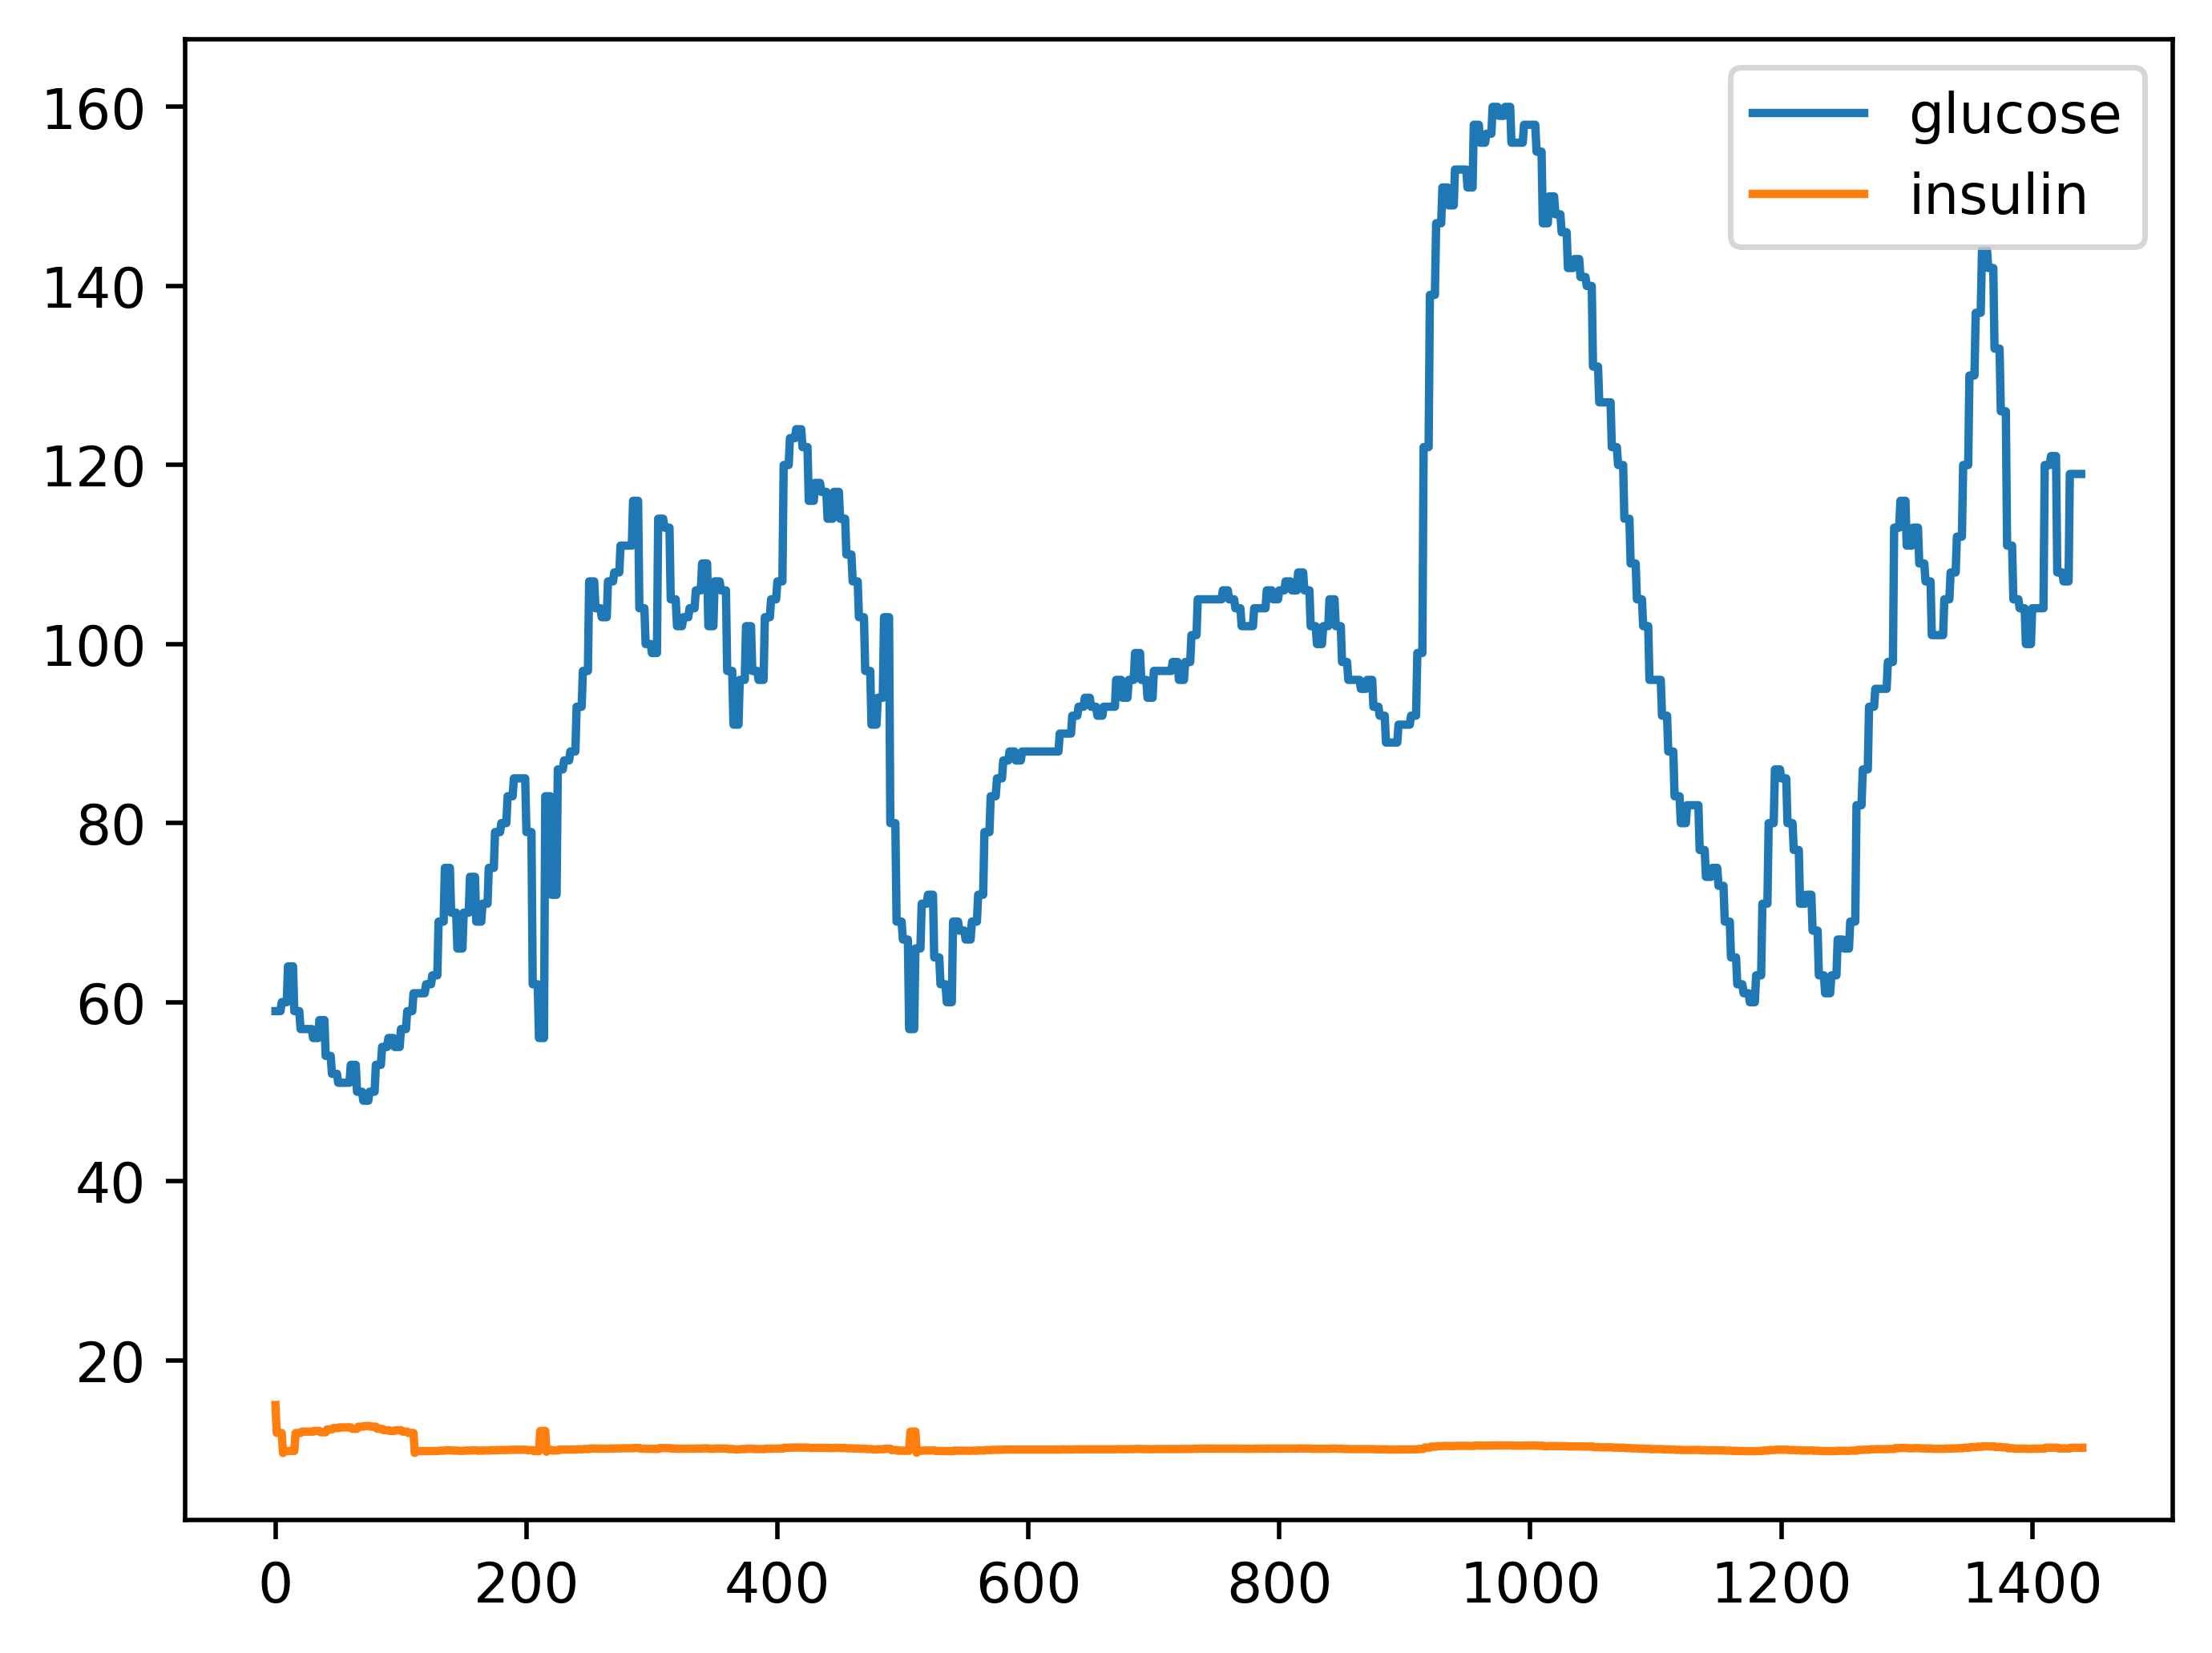

In [33]:
plt.plot(range(1440), df_expanded["iOS G7"], label='glucose')
plt.plot(range(1441), u, label='insulin')
plt.legend()
plt.show()